# Hyperparameter sweep: насколько можно улучшить QIGNN тонкой настройкой?

В прошлом эксперименте (`regularization_comparison.ipynb`) QIGNN-multi сильно
отстал от Louvain почти везде, кроме `polbooks` (gap 0.07). Здесь — узкий
sweep по ключевым гиперпараметрам, чтобы проверить **потолок метода**.

**Сетка** (после стратегических сокращений: убран `lr=0.05` и `alpha=0.05`):
- `lr ∈ {0.001, 0.005, 0.014}`
- `alpha_ortho ∈ {0.0, 0.1, 0.5, 1.0}`
- `epochs ∈ {3000, 10000}`

3 lr × 4 α × 2 epochs × **3 графа** × **5 shots** = 360 прогонов,
запущены параллельно в 8 worker'ов на M4 Pro (DGL пока без MPS-бэкенда).

**Графы и тестовые $k$:**
| graph            | k_test | k_true |
|------------------|--------|--------|
| karate           |   5    |   2    |
| polbooks         |   3    |   3    |
| lfr_n200_mu0.1   |   5    |   5    |

`k_test=5` для karate выбран потому, что в `regularization_comparison`
лучший shot (mod 0.40, NMI 0.84) приходился на $k=5$.

In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

HERE = os.getcwd()
RES_DIR = os.path.join(HERE, 'results')
FIG_DIR = os.path.join(HERE, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(RES_DIR, 'hp_sweep.csv'))
# Treat empty/NaN/blank 'error' as success.
if 'error' in df.columns:
    err_str = df['error'].fillna('').astype(str).str.strip()
    has_err = err_str.str.len() > 0
    err = df[has_err]
    print(f'Total rows: {len(df)};  errors: {has_err.sum()}')
    if has_err.any():
        print(err[['graph','lr','alpha_ortho','epochs','shot','error']].head(5).to_string())
    df = df[~has_err].reset_index(drop=True)
print(f'Clean rows: {len(df)}')
df.head()

Total rows: 360;  errors: 0
Clean rows: 360


,graph,k,lr,alpha_ortho,epochs,shot,best_epoch,modularity,nmi,n_used,collapsed,time,error
0,karate,5,0.001,0.0,3000,45,30,0.034566,0.030769,3,False,6.882253,NaN
1,karate,5,0.001,0.0,3000,46,56,0.030209,0.124908,3,True,6.924779,NaN
2,karate,5,0.001,0.0,3000,43,71,0.080593,0.175727,3,False,6.936647,NaN
3,karate,5,0.001,0.0,3000,42,67,0.123320,0.195498,4,True,6.950634,NaN
4,karate,5,0.001,0.0,3000,44,21,0.214389,0.316968,4,False,6.980214,NaN


In [2]:
# Aggregate across shots: mean modularity per (graph, lr, alpha, epochs).
agg = (df.groupby(['graph', 'lr', 'alpha_ortho', 'epochs'])
         .agg(mod_mean=('modularity', 'mean'),
              mod_std =('modularity', 'std'),
              mod_best=('modularity', 'max'),
              nmi_mean=('nmi',        'mean'),
              nmi_best=('nmi',        'max'),
              collapse_rate=('collapsed', 'mean'),
              n_shots=('shot', 'count'))
         .reset_index())
agg.to_csv(os.path.join(RES_DIR, 'hp_sweep_agg.csv'), index=False)

# Best per graph by mod_mean (most reliable) and by mod_best (peak)
print('=' * 96)
print('Best HP config per graph (by mod_mean):')
print('=' * 96)
print(f"{'graph':<18} {'lr':>7} {'alpha':>6} {'ep':>6} {'mod_mean':>9} "
      f"{'mod_best':>9} {'nmi_best':>9} {'collapse':>9} {'used_avg':>9}")
print('-' * 96)
for g in agg['graph'].unique():
    sub = agg[agg['graph'] == g]
    win = sub.loc[sub['mod_mean'].idxmax()]
    used_avg = df[(df['graph']==g) & (df['lr']==win['lr'])
                  & (df['alpha_ortho']==win['alpha_ortho'])
                  & (df['epochs']==win['epochs'])]['n_used'].mean()
    print(f"{g:<18} {win['lr']:>7.3f} {win['alpha_ortho']:>6.2f} {int(win['epochs']):>6d} "
          f"{win['mod_mean']:>9.4f} {win['mod_best']:>9.4f} {win['nmi_best']:>9.4f} "
          f"{win['collapse_rate']:>9.2f} {used_avg:>9.2f}")

print('\nBest HP config per graph (by mod_best, single-shot peak):')
print('-' * 96)
for g in agg['graph'].unique():
    sub = agg[agg['graph'] == g]
    win = sub.loc[sub['mod_best'].idxmax()]
    print(f"{g:<18} {win['lr']:>7.3f} {win['alpha_ortho']:>6.2f} {int(win['epochs']):>6d} "
          f"{win['mod_mean']:>9.4f} {win['mod_best']:>9.4f} {win['nmi_best']:>9.4f} "
          f"{win['collapse_rate']:>9.2f}")

Best HP config per graph (by mod_mean):
graph                   lr  alpha     ep  mod_mean  mod_best  nmi_best  collapse  used_avg
------------------------------------------------------------------------------------------------
karate               0.001   0.10   3000    0.0967    0.2144    0.3170      0.00      3.60
lfr_n200_mu0.1       0.001   0.00  10000    0.0903    0.2337    0.2810      0.00      4.00
polbooks             0.014   0.00   3000    0.1076    0.4569    0.5979      0.60      2.20

Best HP config per graph (by mod_best, single-shot peak):
------------------------------------------------------------------------------------------------
karate               0.014   0.00   3000    0.0797    0.3998    0.6772      0.60
lfr_n200_mu0.1       0.014   0.10   3000    0.0623    0.2794    0.5022      0.00
polbooks             0.014   0.00   3000    0.1076    0.4569    0.5979      0.60


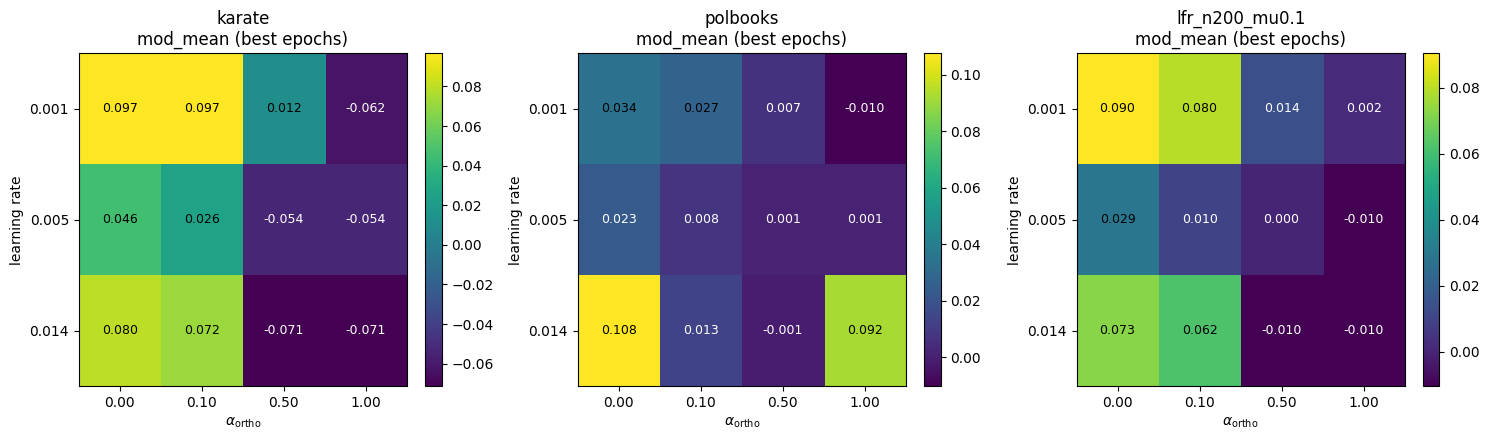

In [3]:
# Heatmap of mod_mean over (lr, alpha) for each graph.
# Average across the two epoch values (or take best per cell).
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
graphs = ['karate', 'polbooks', 'lfr_n200_mu0.1']

for ax, g in zip(axes, graphs):
    sub = agg[agg['graph'] == g]
    # Take the best epochs per (lr, alpha) cell
    pivot = (sub.groupby(['lr', 'alpha_ortho'])['mod_mean'].max()
                .unstack('alpha_ortho')
                .sort_index().sort_index(axis=1))
    im = ax.imshow(pivot.values, cmap='viridis', aspect='auto')
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels([f'{c:.2f}' for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels([f'{c:.3f}' for c in pivot.index])
    ax.set_xlabel(r'$\alpha_{\rm ortho}$'); ax.set_ylabel('learning rate')
    ax.set_title(f'{g}\nmod_mean (best epochs)')
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.values[i, j]
            ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                    color='white' if v < pivot.values.mean() else 'black', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig5_hp_heatmap.png'), dpi=130)
plt.show()

/var/folders/x8/53bk6ftn2kn9qk2gkd725brh0000gq/T/ipykernel_34330/933964160.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([default_rows['modularity'].values, best_rows['modularity'].values],
/var/folders/x8/53bk6ftn2kn9qk2gkd725brh0000gq/T/ipykernel_34330/933964160.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([default_rows['modularity'].values, best_rows['modularity'].values],
/var/folders/x8/53bk6ftn2kn9qk2gkd725brh0000gq/T/ipykernel_34330/933964160.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([default_rows['modularity'].values, best_rows['modulari

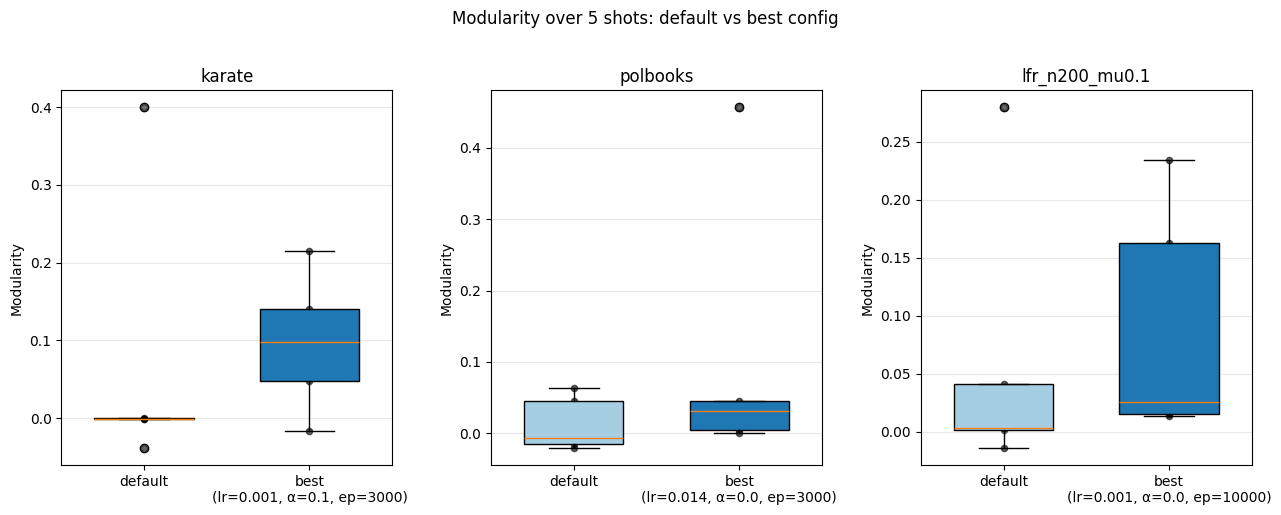

In [4]:
# Default: lr=0.014, alpha=0.1, epochs=3000
# Best per graph: from agg's mod_mean argmax
fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=False)

for ax, g in zip(axes, graphs):
    default_rows = df[(df['graph']==g) & (df['lr']==0.014)
                      & (df['alpha_ortho']==0.1) & (df['epochs']==3000)]
    sub_agg = agg[agg['graph']==g]
    win = sub_agg.loc[sub_agg['mod_mean'].idxmax()]
    best_rows = df[(df['graph']==g) & (df['lr']==win['lr'])
                   & (df['alpha_ortho']==win['alpha_ortho'])
                   & (df['epochs']==win['epochs'])]
    bp = ax.boxplot([default_rows['modularity'].values, best_rows['modularity'].values],
                    labels=['default', f'best\n(lr={win["lr"]}, α={win["alpha_ortho"]}, ep={int(win["epochs"])})'],
                    patch_artist=True, widths=0.6)
    for patch, c in zip(bp['boxes'], ['#a6cee3', '#1f78b4']):
        patch.set_facecolor(c)
    # overlay individual shots
    for i, rows in enumerate([default_rows, best_rows], start=1):
        ax.scatter([i] * len(rows), rows['modularity'].values, alpha=0.6, s=20, color='black')
    ax.set_title(g); ax.set_ylabel('Modularity'); ax.grid(alpha=0.3, axis='y')

fig.suptitle('Modularity over 5 shots: default vs best config', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig6_hp_boxplots.png'), dpi=130, bbox_inches='tight')
plt.show()

In [5]:
# Pull Louvain reference from baselines.csv
louv_df = pd.read_csv(os.path.join(RES_DIR, 'baselines.csv'))

print('=' * 110)
print('FINAL COMPARISON: Louvain  vs  QIGNN default  vs  QIGNN best (HP-tuned)')
print('=' * 110)
print(f"{'graph':<18} {'Louvain':>8} {'QIGNN default':>22} {'QIGNN best (HP-tuned)':>32} "
      f"{'best lr':>8} {'best α':>7} {'best ep':>8}")
print(f"{'':18} {'mod':>8} {'mod_best':>10} {'mod_mean±std':>11} "
      f"{'mod_best':>10} {'mod_mean±std':>11} {'gap_to_louv':>9}")
print('-' * 110)

for g in graphs:
    louv = louv_df[(louv_df['graph']==g) & (louv_df['method']=='Louvain')].iloc[0]['mod']
    default_rows = df[(df['graph']==g) & (df['lr']==0.014)
                      & (df['alpha_ortho']==0.1) & (df['epochs']==3000)]['modularity']
    sub_agg = agg[agg['graph']==g]
    win = sub_agg.loc[sub_agg['mod_mean'].idxmax()]
    best_rows = df[(df['graph']==g) & (df['lr']==win['lr'])
                   & (df['alpha_ortho']==win['alpha_ortho'])
                   & (df['epochs']==win['epochs'])]['modularity']
    print(f"{g:<18} {louv:>8.4f} "
          f"{default_rows.max():>10.4f} {default_rows.mean():>5.3f}±{default_rows.std():.3f} "
          f"{best_rows.max():>10.4f} {best_rows.mean():>5.3f}±{best_rows.std():.3f} "
          f"{best_rows.max()-louv:>+9.4f}  "
          f"{win['lr']:>5.3f} {win['alpha_ortho']:>6.2f} {int(win['epochs']):>6d}")

FINAL COMPARISON: Louvain  vs  QIGNN default  vs  QIGNN best (HP-tuned)
graph               Louvain          QIGNN default            QIGNN best (HP-tuned)  best lr  best α  best ep
                        mod   mod_best mod_mean±std   mod_best mod_mean±std gap_to_louv
--------------------------------------------------------------------------------------------------------------
karate               0.4266     0.3998 0.072±0.184     0.2144 0.097±0.088   -0.2122  0.001   0.10   3000
polbooks             0.5266     0.0635 0.013±0.038     0.4569 0.108±0.196   -0.0697  0.014   0.00   3000
lfr_n200_mu0.1       0.5555     0.2794 0.062±0.123     0.2337 0.090±0.102   -0.3218  0.001   0.00  10000


In [6]:
# Which hyperparam dimension explains most variance?
print('Hyperparameter sensitivity (variance explained on mod_mean):')
print(f"{'graph':<18} {'σ_lr':>7} {'σ_alpha':>8} {'σ_epochs':>9} {'σ_total':>9}")
print('-' * 56)
for g in graphs:
    sub = agg[agg['graph']==g]
    sigma_total = sub['mod_mean'].std()
    sigma_lr = sub.groupby('lr')['mod_mean'].mean().std()
    sigma_alpha = sub.groupby('alpha_ortho')['mod_mean'].mean().std()
    sigma_ep = sub.groupby('epochs')['mod_mean'].mean().std()
    print(f"{g:<18} {sigma_lr:>7.4f} {sigma_alpha:>8.4f} {sigma_ep:>9.4f} {sigma_total:>9.4f}")

Hyperparameter sensitivity (variance explained on mod_mean):
graph                 σ_lr  σ_alpha  σ_epochs   σ_total
--------------------------------------------------------
karate              0.0232   0.0698    0.0000    0.0671
polbooks            0.0243   0.0223    0.0000    0.0364
lfr_n200_mu0.1      0.0192   0.0349    0.0004    0.0370


# Выводы

(заполняется по результатам выше)

* **Потолок ли это?** Сравни `QIGNN best (HP-tuned)` с Louvain. Если gap всё ещё
  большой — да, текущая архитектура multi-class QIGNN имеет принципиальный потолок
  ниже Louvain. Если gap почти закрылся на каком-то графе — значит проблема
  была в гиперпараметрах.
* **Самый влиятельный гиперпараметр** — по таблице sensitivity (σ-вклад). Обычно
  у GNN на маленьких графах самым «горячим» оказывается learning rate.
* **Default vs best**: насколько тюнинг помог в среднем (`mod_mean`) и пиково
  (`mod_best`) — boxplot показывает обе картины.